In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lasio

# Data Quality Analysis

This notebook investigates the quality of the raw FORCE 2020 LAS dataset.

The objective is to identify:

- missing target labels
- missing log values
- invalid/sentinel values
- duplicate or problematic depths
- suspicious physical values
- constant or unusable curves
- wells with insufficient usable labelled data

No irreversible cleaning is performed during the initial analysis.
Cleaning decisions will be made only after the quality issues have been quantified.

In [4]:
# ============================================
# Dataset paths
# ============================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "FORCE_2020"

las_files = sorted(DATA_DIR.glob("*.las"))

print("Dataset directory:", DATA_DIR)
print("Number of LAS files:", len(las_files))

assert len(las_files) == 118, (
    f"Expected 118 LAS files, found {len(las_files)}"
)

Dataset directory: /Users/akashray/Lithology_Predictor/data/raw/FORCE_2020
Number of LAS files: 118


In [5]:
# ============================================
# Lithology label coverage per well
# ============================================

LITHOLOGY_CURVE = "FORCE_2020_LITHOFACIES_LITHOLOGY"

label_records = []

for path in las_files:
    las = lasio.read(path)
    df = las.df().reset_index()

    labels = pd.to_numeric(
        df[LITHOLOGY_CURVE],
        errors="coerce"
    )

    total_samples = len(labels)
    labelled_samples = labels.notna().sum()
    missing_labels = labels.isna().sum()

    label_records.append({
        "well_name": path.stem,
        "total_samples": total_samples,
        "labelled_samples": labelled_samples,
        "missing_labels": missing_labels,
        "labelled_percentage": (
            labelled_samples / total_samples * 100
        ),
        "missing_percentage": (
            missing_labels / total_samples * 100
        )
    })

label_coverage = pd.DataFrame(label_records)

display(label_coverage)

,well_name,total_samples,labelled_samples,missing_labels,labelled_percentage,missing_percentage
0,15_9-13,21441,18270,3171,85.210578,14.789422
1,15_9-14,22875,20336,2539,88.900546,11.099454
2,15_9-15,20954,17717,3237,84.551876,15.448124
3,15_9-17,19879,17351,2528,87.283063,12.716937
4,15_9-23,20494,11063,9431,53.981653,46.018347
...,...,...,...,...,...,...
113,35_9-7,17166,10677,6489,62.198532,37.801468
114,35_9-8,18842,4274,14568,22.683367,77.316633
115,36_7-3,16950,3634,13316,21.439528,78.560472
116,7_1-1,17982,16242,1740,90.323657,9.676343


In [6]:
# ============================================
# Wells with lowest label coverage
# ============================================

display(
    label_coverage
    .sort_values("labelled_percentage")
    .head(20)
)

,well_name,total_samples,labelled_samples,missing_labels,labelled_percentage,missing_percentage
81,34_3-1 A,24513,2251,22262,9.182883,90.817117
5,16_1-2,18547,1734,16813,9.349221,90.650779
86,34_5-1 S,22969,2273,20696,9.895947,90.104053
117,7_1-2 S,19586,2041,17545,10.420709,89.579291
8,16_10-2,20131,2437,17694,12.105708,87.894292
107,35_8-4,21927,2709,19218,12.354631,87.645369
98,35_11-13,19119,2430,16689,12.709870,87.290130
99,35_11-15 S,18832,2596,16236,13.785047,86.214953
77,34_11-1,29690,4226,25464,14.233749,85.766251
10,16_10-5,18808,2765,16043,14.701191,85.298809


In [7]:
# ============================================
# Wells with highest label coverage
# ============================================

display(
    label_coverage
    .sort_values(
        "labelled_percentage",
        ascending=False
    )
    .head(20)
)

,well_name,total_samples,labelled_samples,missing_labels,labelled_percentage,missing_percentage
44,25_9-1,16132,16111,21,99.869824,0.130176
101,35_11-6,23734,23674,60,99.747198,0.252802
48,30_3-3,21287,21164,123,99.422183,0.577817
100,35_11-5,21963,21770,193,99.121249,0.878751
58,31_3-1,13361,13236,125,99.064441,0.935559
64,31_5-4 S,11467,11315,152,98.674457,1.325543
70,33_9-1,17606,17278,328,98.136999,1.863001
72,34_10-16 R,25579,25095,484,98.107823,1.892177
66,31_6-8,9727,9533,194,98.005552,1.994448
22,17_11-1,20533,20099,434,97.886329,2.113671


In [8]:
print(
    "Minimum labelled percentage:",
    label_coverage["labelled_percentage"].min()
)

print(
    "Maximum labelled percentage:",
    label_coverage["labelled_percentage"].max()
)

print(
    "Mean labelled percentage:",
    label_coverage["labelled_percentage"].mean()
)

print(
    "Median labelled percentage:",
    label_coverage["labelled_percentage"].median()
)

Minimum labelled percentage: 9.182882552115204
Maximum labelled percentage: 99.86982395239275
Mean labelled percentage: 62.269229136920444
Median labelled percentage: 69.43714216683594


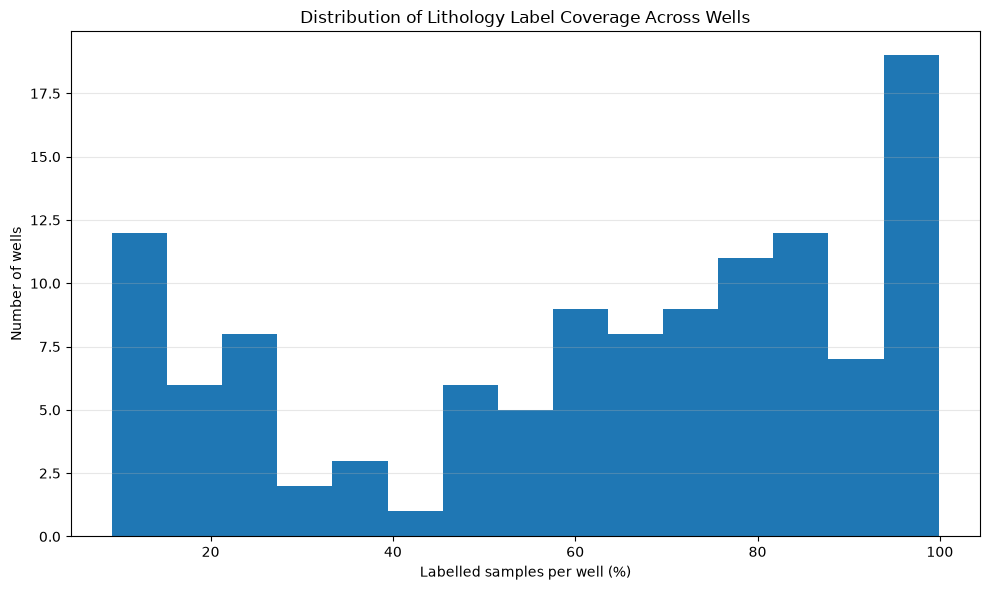

In [9]:
plt.figure(figsize=(10, 6))

plt.hist(
    label_coverage["labelled_percentage"],
    bins=15
)

plt.xlabel("Labelled samples per well (%)")
plt.ylabel("Number of wells")
plt.title("Distribution of Lithology Label Coverage Across Wells")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [10]:
# ============================================
# Investigate missing-label intervals
# ============================================

label_gap_records = []

for path in las_files:
    las = lasio.read(path)
    df = las.df().reset_index()

    depth = pd.to_numeric(
        df["DEPT"],
        errors="coerce"
    )

    labels = pd.to_numeric(
        df[LITHOLOGY_CURVE],
        errors="coerce"
    )

    missing = labels.isna()

    # Find lengths of consecutive missing-label runs
    groups = missing.ne(missing.shift()).cumsum()

    run_lengths = (
        missing
        .groupby(groups)
        .sum()
    )

    missing_runs = run_lengths[
        run_lengths > 0
    ]

    label_gap_records.append({
        "well_name": path.stem,
        "n_missing_runs": len(missing_runs),
        "largest_missing_run_samples": (
            missing_runs.max()
            if len(missing_runs) > 0
            else 0
        ),
        "total_missing_samples": missing.sum()
    })

label_gap_summary = pd.DataFrame(label_gap_records)

display(
    label_gap_summary
    .sort_values(
        "largest_missing_run_samples",
        ascending=False
    )
    .head(20)
)

,well_name,n_missing_runs,largest_missing_run_samples,total_missing_samples
93,34_8-7 R,2,28533,28812
77,34_11-1,2,25370,25464
68,33_5-2,2,23529,23611
49,30_3-5 S,4,22756,23741
81,34_3-1 A,5,21942,22262
84,34_4-10 R,7,21442,21634
86,34_5-1 S,3,20607,20696
104,35_3-7 S,2,19497,19716
87,34_6-1 S,7,19385,19611
107,35_8-4,2,19008,19218


In [12]:
print(
    "Largest missing-label run:",
    label_gap_summary[
        "largest_missing_run_samples"
    ].max(),
    "samples"
)

print(
    "Median number of missing-label runs per well:",
    label_gap_summary[
        "n_missing_runs"
    ].median()
)

Largest missing-label run: 28533 samples
Median number of missing-label runs per well: 2.0


In [13]:
# ============================================
# Inspect missing-label intervals in the worst well
# ============================================

# Find the well with the largest missing-label run
worst_well = (
    label_gap_summary
    .sort_values(
        "largest_missing_run_samples",
        ascending=False
    )
    .iloc[0]["well_name"]
)

print("Well with largest missing-label run:", worst_well)

Well with largest missing-label run: 34_8-7 R


In [14]:
# ============================================
# Load the worst well
# ============================================

worst_path = next(
    path for path in las_files
    if path.stem == worst_well
)

las = lasio.read(worst_path)
df_worst = las.df().reset_index()

depth = pd.to_numeric(
    df_worst["DEPT"],
    errors="coerce"
)

labels = pd.to_numeric(
    df_worst[LITHOLOGY_CURVE],
    errors="coerce"
)

missing = labels.isna()

print("Total samples:", len(labels))
print("Labelled samples:", labels.notna().sum())
print("Missing labels:", labels.isna().sum())
print("Depth range:", depth.min(), "to", depth.max())

Total samples: 35896
Labelled samples: 7084
Missing labels: 28812
Depth range: 23.0 to 5479.04


In [15]:
# ============================================
# Find continuous missing-label intervals
# ============================================

groups = missing.ne(missing.shift()).cumsum()

missing_intervals = []

for _, group in df_worst.groupby(groups):
    
    group_labels = pd.to_numeric(
        group[LITHOLOGY_CURVE],
        errors="coerce"
    )

    if group_labels.isna().all():

        group_depth = pd.to_numeric(
            group["DEPT"],
            errors="coerce"
        ).dropna()

        missing_intervals.append({
            "start_depth": group_depth.min(),
            "end_depth": group_depth.max(),
            "n_samples": len(group),
            "interval_length_m": (
                group_depth.max() - group_depth.min()
            )
        })

missing_intervals_df = pd.DataFrame(
    missing_intervals
).sort_values(
    "n_samples",
    ascending=False
)

display(missing_intervals_df)

,start_depth,end_depth,n_samples,interval_length_m
0,23.000,4359.864,28533,4336.864
1,5436.784,5479.040,279,42.256


In [16]:
# ============================================
# Inspect the boundary of the largest
# missing-label interval
# ============================================

boundary_depth = missing_intervals_df.iloc[0]["end_depth"]

window = 20  # number of samples on each side

boundary_idx = (
    (depth - boundary_depth)
    .abs()
    .idxmin()
)

start_idx = max(0, boundary_idx - window)
end_idx = min(len(df_worst), boundary_idx + window + 1)

inspection_columns = [
    "DEPT",
    "GR",
    "RDEP",
    "RMED",
    "DTC",
    "RHOB",
    "NPHI",
    LITHOLOGY_CURVE
]

inspection_columns = [
    col for col in inspection_columns
    if col in df_worst.columns
]

display(
    df_worst.loc[
        start_idx:end_idx,
        inspection_columns
    ]
)

,DEPT,GR,RDEP,RMED,DTC,RHOB,NPHI,FORCE_2020_LITHOFACIES_LITHOLOGY
28512,4356.824,81.215904,1.664559,1.728911,81.221107,2.350352,0.326482,NaN
28513,4356.976,79.840851,1.721988,1.783628,83.250473,2.346840,0.322130,NaN
28514,4357.128,77.900284,1.761952,1.828370,85.673737,2.346315,0.315627,NaN
28515,4357.280,76.019829,1.749292,1.825621,87.733849,2.349242,0.309823,NaN
28516,4357.432,74.899719,1.736328,1.824563,88.788490,2.357224,0.306882,NaN
28517,4357.584,74.659706,1.707257,1.789448,88.579369,2.365055,0.307556,NaN
28518,4357.736,74.782593,1.657555,1.729851,87.316414,2.370852,0.311014,NaN
28519,4357.888,74.744179,1.664359,1.737189,85.639694,2.368830,0.315338,NaN
28520,4358.040,74.435417,1.737370,1.800643,84.391922,2.359847,0.318544,NaN
28521,4358.192,73.990723,1.853649,1.901480,84.230171,2.344784,0.319492,NaN


118 wells

Regular 0.152 m depth grid

1,431,383 labelled samples

906,256 unlabelled samples

Missing labels are strongly concentrated into continuous intervals

Some wells have very little labelled depth

Need to investigate log values around label boundaries

In [17]:
# ============================================
# Inspect missing-label boundaries in several wells
# ============================================

# Select 5 wells with the largest missing-label runs
worst_wells = (
    label_gap_summary
    .sort_values(
        "largest_missing_run_samples",
        ascending=False
    )
    .head(5)["well_name"]
    .tolist()
)

print("Wells selected for boundary inspection:")
print(worst_wells)

Wells selected for boundary inspection:
['34_8-7 R', '34_11-1', '33_5-2', '30_3-5 S', '34_3-1 A']


In [18]:
# ============================================
# Check whether input logs exist around
# the beginning/end of missing intervals
# ============================================

boundary_checks = []

for well_name in worst_wells:

    path = next(
        p for p in las_files
        if p.stem == well_name
    )

    las = lasio.read(path)
    df = las.df().reset_index()

    depth = pd.to_numeric(
        df["DEPT"],
        errors="coerce"
    )

    labels = pd.to_numeric(
        df[LITHOLOGY_CURVE],
        errors="coerce"
    )

    missing = labels.isna()

    groups = missing.ne(missing.shift()).cumsum()

    for _, group in df.groupby(groups):

        group_labels = pd.to_numeric(
            group[LITHOLOGY_CURVE],
            errors="coerce"
        )

        if not group_labels.isna().all():
            continue

        group_indices = group.index

        start_idx = group_indices.min()
        end_idx = group_indices.max()

        # Inspect one sample immediately before and after
        before_idx = start_idx - 1
        after_idx = end_idx + 1

        if before_idx < 0 or after_idx >= len(df):
            continue

        boundary_checks.append({
            "well_name": well_name,
            "missing_start_depth": depth.loc[start_idx],
            "missing_end_depth": depth.loc[end_idx],
            "label_before": labels.loc[before_idx],
            "label_after": labels.loc[after_idx],
            "GR_before": df.loc[before_idx, "GR"],
            "GR_after": df.loc[after_idx, "GR"],
            "RHOB_before": df.loc[before_idx, "RHOB"],
            "RHOB_after": df.loc[after_idx, "RHOB"],
        })

boundary_checks_df = pd.DataFrame(boundary_checks)

display(boundary_checks_df)

,well_name,missing_start_depth,missing_end_depth,label_before,label_after,GR_before,GR_after,RHOB_before,RHOB_after
0,30_3-5 S,4222.225586,4223.593586,65030.0,65000.0,65.370667,81.468796,2.403004,2.540366
1,30_3-5 S,4371.489586,4372.857586,65030.0,65000.0,80.547989,90.174011,2.573797,2.589477
2,34_3-1 A,3781.584715,3810.920715,80000.0,70000.0,104.562485,74.348755,NaN,2.711820
3,34_3-1 A,3965.048715,3968.240715,65030.0,65030.0,51.496716,57.914989,2.368562,2.590633
4,34_3-1 A,4062.784715,4062.936715,65000.0,30000.0,70.962341,58.073742,2.379572,2.465141


## Input-log missingness

The lithology target and input log curves are analyzed separately.

For each important input curve, we investigate missing values at the well level.
This will help determine whether missingness is distributed uniformly or concentrated
in particular wells or depth intervals.

In [19]:
# ============================================
# Per-well missingness of candidate log curves
# ============================================

candidate_curves = [
    "GR",
    "RDEP",
    "RMED",
    "DTC",
    "RHOB",
    "NPHI",
    "CALI",
    "DRHO"
]

feature_missing_records = []

for path in las_files:
    las = lasio.read(path)
    df = las.df().reset_index()

    for curve in candidate_curves:

        if curve not in df.columns:
            feature_missing_records.append({
                "well_name": path.stem,
                "curve": curve,
                "n_samples": len(df),
                "n_missing": len(df),
                "missing_percentage": 100.0
            })
            continue

        missing_count = df[curve].isna().sum()

        feature_missing_records.append({
            "well_name": path.stem,
            "curve": curve,
            "n_samples": len(df),
            "n_missing": missing_count,
            "missing_percentage": (
                missing_count / len(df) * 100
            )
        })

feature_missing = pd.DataFrame(feature_missing_records)

display(feature_missing.head(20))

,well_name,curve,n_samples,n_missing,missing_percentage
0,15_9-13,GR,21441,541,2.523203
1,15_9-13,RDEP,21441,485,2.262021
2,15_9-13,RMED,21441,484,2.257357
3,15_9-13,DTC,21441,159,0.741570
4,15_9-13,RHOB,21441,3096,14.439625
5,15_9-13,NPHI,21441,7336,34.214822
6,15_9-13,CALI,21441,3096,14.439625
7,15_9-13,DRHO,21441,3096,14.439625
8,15_9-14,GR,22875,73,0.319126
9,15_9-14,RDEP,22875,16,0.069945


In [20]:
# ============================================
# Missingness statistics by curve
# ============================================

feature_missing_summary = (
    feature_missing
    .groupby("curve")["missing_percentage"]
    .agg([
        "min",
        "median",
        "mean",
        "max"
    ])
    .sort_values("mean", ascending=False)
)

display(feature_missing_summary)

,min,median,mean,max
curve,,,,
NPHI,0.010281,52.848869,53.924983,91.555192
DRHO,0.303362,39.633119,42.777703,100.000000
RHOB,0.000000,37.129048,39.931181,91.744103
CALI,0.007554,30.767187,37.743437,100.000000
DTC,0.000000,15.337239,23.564949,90.745157
RMED,0.000000,3.537389,10.338079,100.000000
RDEP,0.003837,1.786972,5.008061,80.908865
GR,0.002786,0.576301,2.004973,39.033432


<Figure size 1200x700 with 0 Axes>

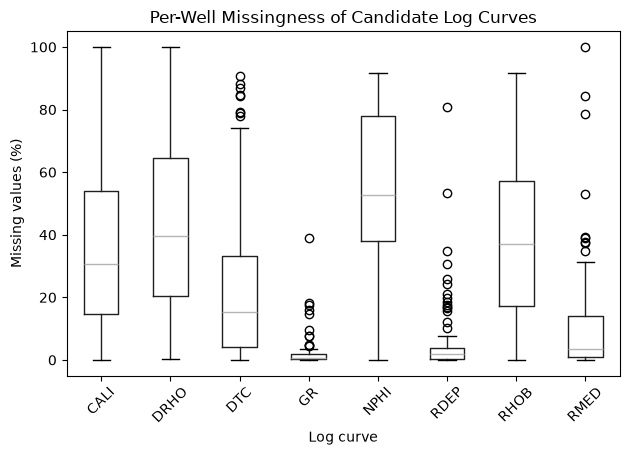

In [21]:
# ============================================
# Distribution of missingness by curve
# ============================================

plt.figure(figsize=(12, 7))

feature_missing.boxplot(
    column="missing_percentage",
    by="curve",
    grid=False
)

plt.title("Per-Well Missingness of Candidate Log Curves")
plt.suptitle("")

plt.xlabel("Log curve")
plt.ylabel("Missing values (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Continuous missing intervals in input logs

Missing values are investigated as continuous depth intervals rather than only
as overall percentages.

This helps distinguish isolated missing samples from long sections where a
logging measurement is unavailable.

In [22]:
# ============================================
# Analyze continuous missing intervals
# for candidate log curves
# ============================================

log_missing_runs = []

for path in las_files:

    las = lasio.read(path)
    df = las.df().reset_index()

    for curve in candidate_curves:

        if curve not in df.columns:
            continue

        missing = df[curve].isna()

        groups = missing.ne(
            missing.shift()
        ).cumsum()

        run_lengths = (
            missing
            .groupby(groups)
            .sum()
        )

        missing_runs = run_lengths[
            run_lengths > 0
        ]

        log_missing_runs.append({
            "well_name": path.stem,
            "curve": curve,
            "n_missing_runs": len(missing_runs),
            "largest_missing_run_samples": (
                missing_runs.max()
                if len(missing_runs) > 0
                else 0
            ),
            "total_missing_samples": missing.sum()
        })

log_missing_runs_df = pd.DataFrame(
    log_missing_runs
)

display(
    log_missing_runs_df
    .sort_values(
        "largest_missing_run_samples",
        ascending=False
    )
    .head(30)
)

,well_name,curve,n_missing_runs,largest_missing_run_samples,total_missing_samples
381,29_6-1,DRHO,2,26252,26277
379,29_6-1,NPHI,2,26252,26277
378,29_6-1,RHOB,2,26252,26277
617,34_11-1,RHOB,2,25339,25427
618,34_11-1,NPHI,4,25333,25458
619,34_11-1,CALI,2,25330,25423
331,25_7-2,NPHI,2,24758,25357
547,33_5-2,NPHI,2,23490,23550
610,34_10-35,NPHI,3,23230,23236
393,30_3-5 S,DTC,2,23212,24430


In [24]:
# ============================================
# Missing-run statistics by curve
# ============================================

log_missing_run_summary = (
    log_missing_runs_df
    .groupby("curve")
    .agg(
        median_missing_runs=(
            "n_missing_runs",
            "median"
        ),
        mean_missing_runs=(
            "n_missing_runs",
            "mean"
        ),
        max_missing_run_samples=(
            "largest_missing_run_samples",
            "max"
        ),
        median_largest_run=(
            "largest_missing_run_samples",
            "median"
        )
    )
    .sort_values(
        "max_missing_run_samples",
        ascending=False
    )
)

display(log_missing_run_summary)

,median_missing_runs,mean_missing_runs,max_missing_run_samples,median_largest_run
curve,,,,
DRHO,2.0,2.456140,26252,6253.5
NPHI,2.0,2.355932,26252,9292.0
RHOB,2.0,2.652542,26252,6003.0
CALI,2.0,2.042373,25330,5683.0
DTC,2.0,2.110169,23212,2740.0
RDEP,2.0,2.110169,22754,339.0
RMED,3.0,4.529915,22754,469.0
GR,2.0,1.889831,5790,80.0


## Sentinel and NULL-value investigation

Missing measurements may be represented either as NaN values or as
special numerical sentinel values.

Before preprocessing, we inspect the LAS NULL definition and search
for repeated suspicious values in the candidate log curves.

In [25]:
# ============================================
# Inspect LAS NULL definition
# ============================================

null_values = []

for path in las_files:

    las = lasio.read(path)

    null_value = None

    try:
        null_value = las.well.NULL.value
    except Exception:
        pass

    null_values.append({
        "well_name": path.stem,
        "null_value": null_value
    })

null_values_df = pd.DataFrame(null_values)

display(
    null_values_df["null_value"]
    .value_counts(dropna=False)
)

null_value
-999.25    118
Name: count, dtype: int64

In [28]:
# ============================================
# Raw value ranges across the dataset
# ============================================

range_records = []

for path in las_files:

    las = lasio.read(path)
    df = las.df().reset_index()

    for curve in candidate_curves:

        if curve not in df.columns:
            continue

        series = pd.to_numeric(
            df[curve],
            errors="coerce"
        ).dropna()

        if len(series) == 0:
            continue

        range_records.append({
            "well_name": path.stem,
            "curve": curve,
            "min": series.min(),
            "max": series.max(),
            "median": series.median()
        })

raw_ranges = pd.DataFrame(range_records)

display(
    raw_ranges
    .groupby("curve")
    .agg({
        "min": "min",
        "max": "max",
        "median": "median"
    })
)

,min,max,median
curve,,,
CALI,2.340806,32.111065,12.450403
DRHO,-7429.338867,49.834522,0.003304
DTC,0.000000,320.478882,115.012657
GR,-15.628183,1141.292114,70.513172
NPHI,-0.056691,0.999570,0.321780
RDEP,0.000100,1999.997070,1.382071
RHOB,0.000000,3.457820,2.311750
RMED,-0.008419,1999.948120,1.372628


In [29]:
if sentinel_df.empty:
    print("No explicit sentinel values found in the candidate curves.")
else:
    display(
        sentinel_df.sort_values(
            "count",
            ascending=False
        )
    )

No explicit sentinel values found in the candidate curves.


## Physical-value anomaly investigation

The raw dataset contains some extreme or physically unusual values.
Before deciding whether these values are invalid, we quantify their
frequency and inspect their depth locations.

In [30]:
# ============================================
# Investigate extreme / unusual values
# ============================================

anomaly_records = []

for path in las_files:

    las = lasio.read(path)
    df = las.df().reset_index()

    for curve in candidate_curves:

        if curve not in df.columns:
            continue

        series = pd.to_numeric(
            df[curve],
            errors="coerce"
        )

        anomaly_records.append({
            "well_name": path.stem,
            "curve": curve,

            # Number of valid samples
            "n_valid": series.notna().sum(),

            # Negative values
            "n_negative": (series < 0).sum(),

            # Zero values
            "n_zero": (series == 0).sum(),

            # Very large absolute values
            "n_abs_gt_1000": (series.abs() > 1000).sum(),

            # Extremely large absolute values
            "n_abs_gt_5000": (series.abs() > 5000).sum(),

            # Minimum / maximum
            "min": series.min(),
            "max": series.max()
        })

anomaly_df = pd.DataFrame(anomaly_records)

display(
    anomaly_df
    .groupby("curve")
    .agg({
        "n_valid": "sum",
        "n_negative": "sum",
        "n_zero": "sum",
        "n_abs_gt_1000": "sum",
        "n_abs_gt_5000": "sum",
        "min": "min",
        "max": "max"
    })
)

,n_valid,n_negative,n_zero,n_abs_gt_1000,n_abs_gt_5000,min,max
curve,,,,,,,
CALI,1461913,0,0,0,0,2.340806,32.111065
DRHO,1324910,562829,4740,1,1,-7429.338867,49.834522
DTC,1793708,0,9039,0,0,0.000000,320.478882
GR,2297684,2289,414,5,0,-15.628183,1141.292114
NPHI,1033603,1018,10,0,0,-0.056691,0.999570
RDEP,2219193,0,0,5201,0,0.000100,1999.997070
RHOB,1396517,0,21910,0,0,0.000000,3.457820
RMED,2092874,7,0,1633,0,-0.008419,1999.948120


In [31]:
# ============================================
# Locate extreme DRHO values
# ============================================

drho_extremes = []

for path in las_files:

    las = lasio.read(path)
    df = las.df().reset_index()

    if "DRHO" not in df.columns:
        continue

    depth_col = df.columns[0]

    drho = pd.to_numeric(
        df["DRHO"],
        errors="coerce"
    )

    mask = drho.abs() > 100

    if mask.any():

        temp = pd.DataFrame({
            "well_name": path.stem,
            "depth": df.loc[mask, depth_col],
            "DRHO": drho.loc[mask]
        })

        drho_extremes.append(temp)

if drho_extremes:

    drho_extremes_df = pd.concat(
        drho_extremes,
        ignore_index=True
    )

    display(
        drho_extremes_df
        .sort_values(
            "DRHO",
            key=lambda x: x.abs(),
            ascending=False
        )
        .head(30)
    )

else:

    print("No DRHO values with |DRHO| > 100 found.")

,well_name,depth,DRHO
0,25_9-1,2526.59,-7429.338867


The anomaly counts show:

DRHO: 562,829 negative values out of 1,324,910 valid samples, so negative DRHO is common and cannot be treated as automatically invalid.

But there is exactly one extremely abnormal DRHO value:
Well: 25_9-1
Depth: 2526.590 m
DRHO: -7429.338867

GR: only 2,289 negative values and 5 values with |GR| > 1000; worth inspecting, but not enough evidence to delete them.

RDEP: 5,201 values >1000, but none negative. Since resistivity can legitimately span a large range, we should not call these errors yet.

RMED: 1,633 values >1000 and only 7 negative values.

DTC: 9,039 zeros. These need investigation because zero sonic slowness is not physically meaningful.

RHOB: 21,910 zeros. These are also suspicious and likely represent bad/missing measurements rather than real density.

NPHI: only 10 zeros and 1,018 negative values; the negatives need some inspection, but many are small.

CALI: no negative or zero values.

In [32]:
# ============================================
# Inspect the extreme DRHO value
# ============================================

well_name = "25_9-1"
target_depth = 2526.590

path = next(
    p for p in las_files
    if p.stem == well_name
)

las = lasio.read(path)
df = las.df().reset_index()

depth_col = df.columns[0]

# Find rows around the suspicious depth
window = df[
    (df[depth_col] >= target_depth - 1.0) &
    (df[depth_col] <= target_depth + 1.0)
].copy()

display(
    window[
        [depth_col] +
        [
            c for c in candidate_curves
            if c in window.columns
        ]
    ]
)

,DEPT,GR,RDEP,RMED,DTC,RHOB,NPHI,CALI,DRHO
16089,2525.678,130.512619,2.979362,2.979362,NaN,2.486771,NaN,8.228930,0.162276
16090,2525.830,105.636192,2.982062,2.982062,NaN,2.479213,NaN,8.227565,0.166779
16091,2525.982,107.965813,2.435510,2.435510,NaN,2.469712,NaN,8.226046,0.171768
16092,2526.134,100.466049,1.874109,1.874109,NaN,2.458056,NaN,8.225890,0.175254
16093,2526.286,84.908226,1.834382,1.834382,NaN,2.446839,NaN,8.226868,0.178244
16094,2526.438,84.678329,1.887268,1.887268,NaN,2.454262,NaN,8.228201,0.179745
16095,2526.590,96.585960,2.062392,2.062392,NaN,2.509072,NaN,8.229455,-7429.338867
16096,2526.742,109.039299,2.275338,2.275338,NaN,2.565662,NaN,8.324678,NaN
16097,2526.894,107.221375,2.017192,2.017192,NaN,NaN,NaN,NaN,NaN
16098,2527.046,97.112297,1.711890,1.711890,NaN,NaN,NaN,NaN,NaN


## Investigation of zero-valued log measurements

Zero values are investigated separately because zero may be physically
meaningful for some quantities but generally requires careful interpretation
for measurements such as density and sonic slowness.

In [33]:
# ============================================
# Investigate zero-valued DTC and RHOB samples
# ============================================

zero_records = []

for path in las_files:

    las = lasio.read(path)
    df = las.df().reset_index()

    depth_col = df.columns[0]

    for curve in ["DTC", "RHOB"]:

        if curve not in df.columns:
            continue

        series = pd.to_numeric(
            df[curve],
            errors="coerce"
        )

        zero_mask = series == 0

        if zero_mask.any():

            zero_records.append({
                "well_name": path.stem,
                "curve": curve,
                "n_zero": int(zero_mask.sum()),
                "first_zero_depth": df.loc[
                    zero_mask, depth_col
                ].iloc[0],
                "last_zero_depth": df.loc[
                    zero_mask, depth_col
                ].iloc[-1]
            })

zero_df = pd.DataFrame(zero_records)

display(
    zero_df.sort_values(
        ["curve", "n_zero"],
        ascending=[True, False]
    )
)

,well_name,curve,n_zero,first_zero_depth,last_zero_depth
0,34_8-7 R,DTC,9039,23.0,1396.776
1,34_8-7 R,RHOB,21910,23.0,5479.040


In [34]:
# ============================================
# Zero-run analysis
# ============================================

zero_run_records = []

for path in las_files:

    las = lasio.read(path)
    df = las.df().reset_index()

    depth_col = df.columns[0]

    for curve in ["DTC", "RHOB"]:

        if curve not in df.columns:
            continue

        series = pd.to_numeric(
            df[curve],
            errors="coerce"
        )

        zero_mask = series == 0

        groups = (
            zero_mask
            .ne(zero_mask.shift())
            .cumsum()
        )

        zero_runs = (
            zero_mask
            .groupby(groups)
            .sum()
        )

        zero_runs = zero_runs[
            zero_runs > 0
        ]

        zero_run_records.append({
            "well_name": path.stem,
            "curve": curve,
            "n_zero_runs": len(zero_runs),
            "largest_zero_run_samples": (
                int(zero_runs.max())
                if len(zero_runs) > 0
                else 0
            )
        })

zero_run_df = pd.DataFrame(
    zero_run_records
)

display(
    zero_run_df
    .sort_values(
        "largest_zero_run_samples",
        ascending=False
    )
    .head(30)
)

,well_name,curve,n_zero_runs,largest_zero_run_samples
187,34_8-7 R,RHOB,3,20982
186,34_8-7 R,DTC,1,9039
0,15_9-13,DTC,0,0
162,34_3-1 A,DTC,0,0
150,34_10-33,DTC,0,0
151,34_10-33,RHOB,0,0
152,34_10-35,DTC,0,0
153,34_10-35,RHOB,0,0
154,34_11-1,DTC,0,0
155,34_11-1,RHOB,0,0


In [35]:
# ============================================
# Inspect boundaries of DTC/RHOB zero sections
# ============================================

well_name = "34_8-7 R"

path = next(
    p for p in las_files
    if p.stem == well_name
)

las = lasio.read(path)
df = las.df().reset_index()

depth_col = df.columns[0]

# DTC boundary
dtc_zero = df["DTC"] == 0

dtc_first = dtc_zero.idxmax()
dtc_last = df.index[dtc_zero].max()

# RHOB boundary
rhob_zero = df["RHOB"] == 0

rhob_indices = df.index[rhob_zero]

rhob_first = rhob_indices.min()
rhob_last = rhob_indices.max()

print("DTC zero interval:")
print(
    df.loc[
        max(0, dtc_first - 3):
        min(len(df), dtc_last + 4),
        [depth_col, "DTC", "RHOB", "GR", "RDEP"]
    ]
)

print("\nRHOB zero interval boundaries:")
print(
    df.loc[
        max(0, rhob_first - 3):
        min(len(df), rhob_last + 4),
        [depth_col, "RHOB", "DTC", "GR", "RDEP"]
    ]
)

DTC zero interval:
          DEPT       DTC  RHOB         GR      RDEP
0       23.000  0.000000   0.0 -15.000000       NaN
1       23.152  0.000000   0.0 -15.000000       NaN
2       23.304  0.000000   0.0 -15.000000       NaN
3       23.456  0.000000   0.0 -15.000000       NaN
4       23.608  0.000000   0.0 -15.000000       NaN
...        ...       ...   ...        ...       ...
9038  1396.776  0.000000   0.0  68.023323  0.858540
9039  1396.928  0.093699   0.0  68.071838  0.855075
9040  1397.080  0.809266   0.0  68.299370  0.846694
9041  1397.232  3.207896   0.0  68.841484  0.835208
9042  1397.384  8.262777   0.0  69.677612  0.823677

[9043 rows x 5 columns]

RHOB zero interval boundaries:
           DEPT  RHOB        DTC    GR  RDEP
0        23.000   0.0   0.000000 -15.0   NaN
1        23.152   0.0   0.000000 -15.0   NaN
2        23.304   0.0   0.000000 -15.0   NaN
3        23.456   0.0   0.000000 -15.0   NaN
4        23.608   0.0   0.000000 -15.0   NaN
...         ...   ...        .

In [36]:
# ============================================
# Find actual zero intervals for RHOB and DTC
# ============================================

for curve in ["DTC", "RHOB"]:

    series = pd.to_numeric(
        df[curve],
        errors="coerce"
    )

    zero_mask = series == 0

    groups = (
        zero_mask
        .ne(zero_mask.shift())
        .cumsum()
    )

    runs = []

    for group_id, group in zero_mask.groupby(groups):

        if not group.any():
            continue

        indices = group.index

        start_idx = indices[0]
        end_idx = indices[-1]

        runs.append({
            "curve": curve,
            "start_depth": df.loc[start_idx, depth_col],
            "end_depth": df.loc[end_idx, depth_col],
            "n_samples": len(indices),
            "interval_length_m": (
                df.loc[end_idx, depth_col]
                - df.loc[start_idx, depth_col]
            )
        })

    zero_intervals = pd.DataFrame(runs)

    print(f"\n{curve} zero intervals:")
    display(zero_intervals)


DTC zero intervals:


,curve,start_depth,end_depth,n_samples,interval_length_m
0,DTC,23.0,1396.776,9039,1373.776



RHOB zero intervals:


,curve,start_depth,end_depth,n_samples,interval_length_m
0,RHOB,23.000,3212.112,20982,3189.112
1,RHOB,3838.048,3948.704,729,110.656
2,RHOB,5448.944,5479.040,199,30.096


In [37]:
# ============================================
# Investigate negative GR values
# ============================================

negative_gr_records = []

for path in las_files:

    las = lasio.read(path)
    temp = las.df().reset_index()

    depth_col_temp = temp.columns[0]

    gr = pd.to_numeric(
        temp["GR"],
        errors="coerce"
    )

    mask = gr < 0

    if mask.any():

        negative_gr_records.append({
            "well_name": path.stem,
            "n_negative": int(mask.sum()),
            "min_GR": gr[mask].min(),
            "first_negative_depth": (
                temp.loc[mask, depth_col_temp].iloc[0]
            ),
            "last_negative_depth": (
                temp.loc[mask, depth_col_temp].iloc[-1]
            )
        })

negative_gr_df = pd.DataFrame(
    negative_gr_records
)

display(
    negative_gr_df
    .sort_values(
        "n_negative",
        ascending=False
    )
)

,well_name,n_negative,min_GR,first_negative_depth,last_negative_depth
2,34_8-7 R,2273,-15.628183,23.000000,5439.824000
0,16_11-1 ST3,14,-0.703000,88.593201,90.569201
1,25_6-2,2,-2.095971,2375.448000,2375.600000


In [38]:
# ============================================
# Inspect negative GR intervals
# ============================================

for well_name in negative_gr_df["well_name"]:

    path = next(
        p for p in las_files
        if p.stem == well_name
    )

    las = lasio.read(path)
    temp = las.df().reset_index()

    depth_col_temp = temp.columns[0]

    gr = pd.to_numeric(
        temp["GR"],
        errors="coerce"
    )

    negative_mask = gr < 0

    groups = (
        negative_mask
        .ne(negative_mask.shift())
        .cumsum()
    )

    intervals = []

    for group_id, group in negative_mask.groupby(groups):

        if not group.any():
            continue

        idx = group.index

        intervals.append({
            "well_name": well_name,
            "start_depth": temp.loc[idx[0], depth_col_temp],
            "end_depth": temp.loc[idx[-1], depth_col_temp],
            "n_samples": len(idx),
            "min_GR": gr.loc[idx].min(),
            "max_GR": gr.loc[idx].max()
        })

    intervals_df = pd.DataFrame(intervals)

    print(f"\nNegative GR intervals — {well_name}")
    display(intervals_df)


Negative GR intervals — 16_11-1 ST3


,well_name,start_depth,end_depth,n_samples,min_GR,max_GR
0,16_11-1 ST3,88.593201,90.569201,14,-0.703,-0.155493



Negative GR intervals — 25_6-2


,well_name,start_depth,end_depth,n_samples,min_GR,max_GR
0,25_6-2,2375.448,2375.6,2,-2.095971,-1.076712



Negative GR intervals — 34_8-7 R


,well_name,start_depth,end_depth,n_samples,min_GR,max_GR
0,34_8-7 R,23.000,368.040,2271,-15.628183,-1.303876
1,34_8-7 R,5439.672,5439.824,2,-6.382940,-2.155296


In [39]:
# ============================================
# Inspect the large negative-GR interval
# ============================================

well_name = "34_8-7 R"

path = next(
    p for p in las_files
    if p.stem == well_name
)

las = lasio.read(path)
inspect_df = las.df().reset_index()

depth_col = inspect_df.columns[0]

# Focus around the negative-GR interval
mask = (
    (inspect_df[depth_col] >= 350) &
    (inspect_df[depth_col] <= 385)
)

boundary_df = inspect_df.loc[
    mask,
    [
        depth_col,
        "GR",
        "RDEP",
        "RMED",
        "DTC",
        "RHOB",
        "NPHI",
        "CALI"
    ]
]

display(boundary_df)

,DEPT,GR,RDEP,RMED,DTC,RHOB,NPHI,CALI
2152,350.104,-15.000000,NaN,NaN,0.0,0.0,NaN,NaN
2153,350.256,-15.000000,NaN,NaN,0.0,0.0,NaN,NaN
2154,350.408,-15.000000,NaN,NaN,0.0,0.0,NaN,NaN
2155,350.560,-15.000000,NaN,NaN,0.0,0.0,NaN,NaN
2156,350.712,-15.000000,NaN,NaN,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...
2377,384.304,39.874619,0.711547,NaN,0.0,0.0,NaN,NaN
2378,384.456,39.342686,0.715463,NaN,0.0,0.0,NaN,NaN
2379,384.608,39.997604,0.716907,NaN,0.0,0.0,NaN,NaN
2380,384.760,42.549831,0.717176,NaN,0.0,0.0,NaN,NaN


In [40]:
# Beginning of the suspicious interval

mask = (
    (inspect_df[depth_col] >= 15) &
    (inspect_df[depth_col] <= 35)
)

display(
    inspect_df.loc[
        mask,
        [
            depth_col,
            "GR",
            "RDEP",
            "RMED",
            "DTC",
            "RHOB",
            "NPHI",
            "CALI"
        ]
    ]
)

,DEPT,GR,RDEP,RMED,DTC,RHOB,NPHI,CALI
0,23.000,-15.0,NaN,NaN,0.0,0.0,NaN,NaN
1,23.152,-15.0,NaN,NaN,0.0,0.0,NaN,NaN
2,23.304,-15.0,NaN,NaN,0.0,0.0,NaN,NaN
3,23.456,-15.0,NaN,NaN,0.0,0.0,NaN,NaN
4,23.608,-15.0,NaN,NaN,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...
74,34.248,-15.0,NaN,NaN,0.0,0.0,NaN,NaN
75,34.400,-15.0,NaN,NaN,0.0,0.0,NaN,NaN
76,34.552,-15.0,NaN,NaN,0.0,0.0,NaN,NaN
77,34.704,-15.0,NaN,NaN,0.0,0.0,NaN,NaN


In [41]:
# ============================================
# Inspect the extreme DRHO value
# ============================================

well_name = "25_9-1"

path = next(
    p for p in las_files
    if p.stem == well_name
)

las = lasio.read(path)
drho_df = las.df().reset_index()

depth_col = drho_df.columns[0]

mask = (
    (drho_df[depth_col] >= 2525.5) &
    (drho_df[depth_col] <= 2527.5)
)

display(
    drho_df.loc[
        mask,
        [
            depth_col,
            "GR",
            "RDEP",
            "RMED",
            "DTC",
            "RHOB",
            "NPHI",
            "CALI",
            "DRHO"
        ]
    ]
)

,DEPT,GR,RDEP,RMED,DTC,RHOB,NPHI,CALI,DRHO
16088,2525.526,136.039551,2.629672,2.629672,NaN,2.494231,NaN,8.228986,0.159524
16089,2525.678,130.512619,2.979362,2.979362,NaN,2.486771,NaN,8.228930,0.162276
16090,2525.830,105.636192,2.982062,2.982062,NaN,2.479213,NaN,8.227565,0.166779
16091,2525.982,107.965813,2.435510,2.435510,NaN,2.469712,NaN,8.226046,0.171768
16092,2526.134,100.466049,1.874109,1.874109,NaN,2.458056,NaN,8.225890,0.175254
16093,2526.286,84.908226,1.834382,1.834382,NaN,2.446839,NaN,8.226868,0.178244
16094,2526.438,84.678329,1.887268,1.887268,NaN,2.454262,NaN,8.228201,0.179745
16095,2526.590,96.585960,2.062392,2.062392,NaN,2.509072,NaN,8.229455,-7429.338867
16096,2526.742,109.039299,2.275338,2.275338,NaN,2.565662,NaN,8.324678,NaN
16097,2526.894,107.221375,2.017192,2.017192,NaN,NaN,NaN,NaN,NaN


## Preprocessing Decisions

Based on the data-quality analysis:

- Unlabelled lithology samples will not be used for supervised training.
- DTC <= 0 is treated as invalid and converted to NaN.
- RHOB <= 0 is treated as invalid and converted to NaN.
- Negative GR values are treated as invalid and converted to NaN.
- Non-positive RDEP/RMED values are treated as invalid before log transformation.
- High missingness in DTC and RHOB does not by itself justify removing an entire well.
- Large missing intervals will not be blindly interpolated.
- Missing-value handling will be evaluated during preprocessing.
- Train-derived preprocessing parameters will be calculated using training wells only.